In [1]:
import scanpy as sc
import pandas as pd
import squidpy as sq
from datetime import datetime
import scanpy as sc
import squidpy as sq
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
import glob

/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/tscc/nfs/home/cmiciano/miniconda3/envs/spatial/lib/python3.11/site-packages/anndata/__init__.py:44: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead

In [2]:
### score the gene pathways for mash
### assign all the heps that are in the top 1% 

In [2]:
gsea_df = pd.read_csv('/tscc/lustre/ddn/scratch/welison/Liver_Share/result.depot/250805_WE_fGSEA_RNA_Reupload/GSEA.CP_Hepatocytes_MASH_vs_Control.go.kegg.reactome.hallmark.nothresh.res', sep = "\t")

In [3]:
gsea_df.head()

,pathway,pval,padj,log2err,ES,NES,size,leadingEdge
0,GOBP_2FE_2S_CLUSTER_ASSEMBLY,0.454231,0.692221,0.076477,0.410849,1.017937,11,FXN|NDUFAB1|ISCU|GLRX3|FDX2
1,GOBP_2_OXOGLUTARATE_METABOLIC_PROCESS,0.743902,0.881390,0.068957,-0.262973,-0.803877,17,AADAT|IDH1|L2HGDH
2,GOBP_3_PHOSPHOADENOSINE_5_PHOSPHOSULFATE_METAB...,0.588670,0.785927,0.081527,-0.305605,-0.908216,16,PAPSS1|ENPP1|TPST1
3,GOBP_3_UTR_MEDIATED_MRNA_DESTABILIZATION,0.050676,0.218428,0.261664,0.540896,1.490455,17,DND1|PLEKHN1|TRIM71|ZC3H12D|RBM24|RC3H1|UPF1|K...
4,GOBP_3_UTR_MEDIATED_MRNA_STABILIZATION,0.393740,0.646972,0.081527,0.363504,1.058504,20,MAPK14|TENT4A|HNRNPA0|RBM24|ELAVL4|BOLL|MAPKAP...


In [4]:
gene_sets = [
        "KEGG_ECM_RECEPTOR_INTERACTION"
]

In [ ]:
adata_paths = ['/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/misc/tangram_scores_dist2/HL230324_filt/heps_adata_0.5_tangram_filt.h5ad',
  '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/misc/tangram_scores_dist2/HL20221019_broad_no_mast_filt/heps_adata_0.5_tangram_filt.h5ad',
  '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/misc/tangram_scores_dist2/HL160029_filt/heps_adata_0.5_tangram_filt.h5ad']
#  '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/misc/tangram_scores_dist2/HL170058_filt/adata_0.5_tangram_filt.h5ad']
               

In [5]:
adata_paths = [
  '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/misc/tangram_scores_dist2/HL20221019_broad_no_mast_filt/heps_adata_0.5_tangram_filt.h5ad'
]
    #  '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/misc/tangram_scores_dist2/HL170058_filt/adata_0.5_tangram_filt.h5ad']
               

In [5]:
sample_nm = 'HL20221019_broad_no_mast_filt'

In [6]:
inp_dir = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/tangram/deep_seq_heps_alldonors_highfib_lowfib/'


In [7]:
sp_file_path = os.path.join(inp_dir, sample_nm, 'merge/Post_sp_ct_proj_comb_outer.h5ad')
adata = sc.read_h5ad(sp_file_path)
print(adata)

AnnData object with n_obs × n_vars = 178400 × 17910
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types'
    uns: 'clusters', 'hvg', 'neighbors', 'pca', 'pred_cell_types_colors', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'


In [8]:
adata.obs['celltype_proj'].value_counts()

celltype_proj
Hepatocytes.Zone2        86149
Hepatocytes.Zone3        32992
Hepatocytes.Senescent    32355
Hepatocytes.Zone1        26904
Name: count, dtype: int64

In [9]:
adata.obs['pred_cell_types'].value_counts()

pred_cell_types
Hepatocytes    178400
Name: count, dtype: int64

2025-08-30 17:53:24.687460


/scratch/cmiciano/job_7146120/ipykernel_4130731/3852753937.py:54: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata,


2025-08-30 17:53:35.623592


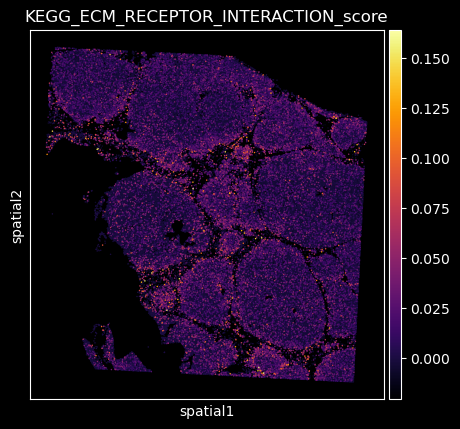

In [10]:
outp = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/'

# List of gene sets you're looping through
#gene_sets = [...]  # your list of GSEA pathway names

# GSEA results as a DataFrame
#gsea_df = pd.read_csv("your_gsea_results.csv")  # or however it's loaded

# Filter GSEA
#filtered_df = gsea_df[(gsea_df['padj'] < 0.05) & (gsea_df['NES'] > 0)]
available_pathways = set(gsea_df['pathway']) #plot all pathways even if not sig, so you can compare

# Search for all relevant .h5ad files
#adata_paths = glob.glob("/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/misc/tangram_scores_dist2/*/adata_0.5_tangram_filt.h5ad")

print(datetime.now())

#for adata_path in adata_paths:
    #adata_path = Path(adata_path)
    
    # Load AnnData
    #adata = sc.read_h5ad(adata_path)
    #adata = sc.read_h5ad('/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/misc/tangram_scores_dist2/HL20221019_broad_no_mast_filt/adata_0.5_tangram_filt.h5ad')

# Extract sample name from folder (e.g., HL20221019_broad_no_mast_filt)
#sample_name = adata_path.parent.name

# Create output directory
#os.makedirs(f"{outp}/fnih_deg_pathways_module_score_mash", exist_ok = True)
#sample_outdir = Path(f"{outp}/fnih_deg_pathways_module_score_mash") / sample_name
#sample_outdir.mkdir(parents=True, exist_ok=True)

#print(f"\n🔁 Processing {sample_name} ...")

for pw_name in gene_sets: #make sure that the pathway plotted is one of the ones in the heatmap
    if pw_name not in available_pathways:
        print(f"  → Skipped {pw_name}: not in filtered GSEA")
        continue

    row = gsea_df[gsea_df['pathway'] == pw_name]
    leading_edge_series = row['leadingEdge']
    if leading_edge_series.isna().any():
        print(f"  → Skipped {pw_name}: missing leadingEdge")
        continue
    
    pw_genes = leading_edge_series.iloc[0].split('|')
    pw_genes = [gene.lower() for gene in pw_genes]

    # Score genes
    sc.tl.score_genes(adata, pw_genes, score_name=f"{pw_name}_score")

    # Spatial plot
    plt.style.use('dark_background')
    sc.pl.spatial(adata, 
          color=[f"{pw_name}_score"],
          cmap = 'inferno',
          size = 4, 
          img_key = None,
          show = False) 

    # Save plot
    #out_path = sample_outdir / f"{pw_name}_score.pdf"
    #plt.savefig(out_path, bbox_inches="tight")
    #plt.close()

#print(f"✅ Done with {sample_name}. Plots saved to {sample_outdir}")

print(datetime.now())

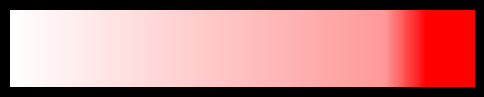

In [11]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# White → Red aggressive
custom_white_red = mcolors.LinearSegmentedColormap.from_list(
    "white_red_toplock",
    [
        (0.0, "#ffffff"),  # White
        (0.9, "#ff9999"),  # Light-medium red at 90%
        (1.0, "#ff0000"),  # Full red for top values
    ]
)

# Fake data for demonstration
values = np.linspace(0, 1, 256)

# Apply percentile clipping so top 10% are same red
percentile_cutoff = 0.9
norm_values = np.clip(values, 0, percentile_cutoff) / percentile_cutoff
norm_values[norm_values > 1] = 1  # Ensure top bin is maxed

# Show the palette
plt.figure(figsize=(6, 1))
plt.imshow(norm_values.reshape(1, -1), aspect="auto", cmap=custom_white_red)
plt.axis("off")
plt.show()


In [12]:
plt.rcdefaults() 

/scratch/cmiciano/job_7146120/ipykernel_4130731/1028507195.py:35: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


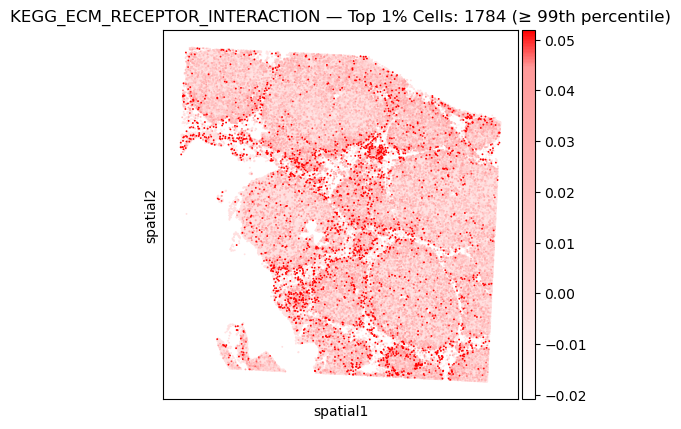

In [13]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import glob
from datetime import datetime

outp = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/'

# Search for all relevant .h5ad files
#adata_paths = glob.glob("/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/misc/tangram_scores_dist2/*/adata_0.5_tangram_filt.h5ad")

# Load GSEA results
#gsea_df = pd.read_csv("your_gsea_results.csv")  # adjust path
#available_pathways = set(gsea_df['pathway'])
#gene_sets = list(available_pathways)  # or use a filtered list if desired



# Loop over percentiles 90–99
for p in range(99, 100):
    
    # Get non-NaN scores
    scores = adata.obs[f"{pw_name}_score"].dropna()

    cutoff = np.percentile(scores, p)
    num_top_cells = (scores >= cutoff).sum()

    plot_title = f"{pw_name} — Top {100-p}% Cells: {num_top_cells} (≥ {p}th percentile)"
    #out_path = sample_outdir / f"crop_{pw_name}_score_red_white_{p}th_percentile.pdf"

    #plt.style.use('dark_background')
    sc.pl.spatial(
        adata,
        color=f"{pw_name}_score",
        size=5,
        img_key=None,
        title=plot_title,
        cmap=custom_white_red,
        vmax=cutoff,
        show=False
    )

    #plt.savefig(out_path, bbox_inches="tight")
    #plt.close()

#print(f"✅ Done with {sample_name}. Plots saved to {sample_outdir}")
#print(datetime.now())


/scratch/cmiciano/job_7146120/ipykernel_4130731/1162505768.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


[<Axes: title={'center': 'KEGG_ECM_RECEPTOR_INTERACTION — Top 1% Cells: 1784 (≥ 99th percentile)'}, xlabel='spatial1', ylabel='spatial2'>]

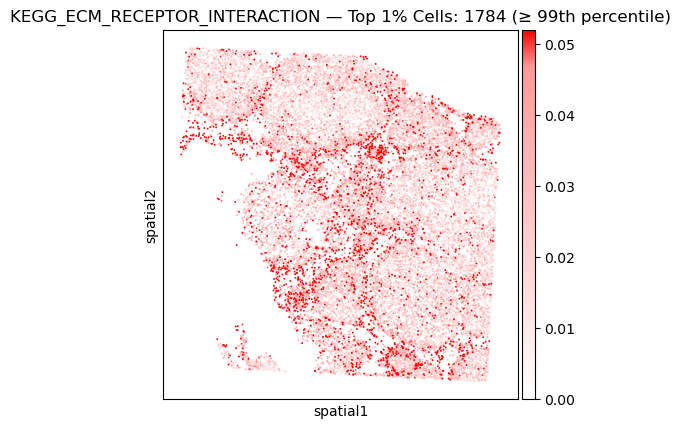

In [14]:
 sc.pl.spatial(
        adata,
        color=f"{pw_name}_score",
        size=5,
        img_key=None,
        title=plot_title,
        cmap=custom_white_red,
        vmax=cutoff,
        vmin = 0,
        show=False
    )



In [15]:
outp

'/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/'

In [16]:
pw_name

'KEGG_ECM_RECEPTOR_INTERACTION'

In [17]:
p

99

In [18]:
colname = f"{pw_name}_top_{100-p}pct"


In [19]:
p

99

In [20]:
colname

'KEGG_ECM_RECEPTOR_INTERACTION_top_1pct'

In [21]:
cutoff

0.05195347897937378

In [22]:
cutoff = np.percentile(scores, p)
num_top_cells = (scores >= cutoff).sum()
num_top_cells

1784

In [23]:
cutoff = np.percentile(scores, p)
num_top_cells = (scores >= cutoff).sum()

# Make a new column for this percentile
colname = f"{pw_name}_top_{100-p}pct"

# Assign "High_score" to the same cells used for num_top_cells
adata.obs[colname] = np.where(
    adata.obs[f"{pw_name}_score"] >= cutoff,
    "High_score",
    "Low_score"
)


In [24]:
adata.obs['KEGG_ECM_RECEPTOR_INTERACTION_top_1pct'].value_counts()

KEGG_ECM_RECEPTOR_INTERACTION_top_1pct
Low_score     176616
High_score      1784
Name: count, dtype: int64

In [25]:
adata.obs['celltype_proj'].value_counts()

celltype_proj
Hepatocytes.Zone2        86149
Hepatocytes.Zone3        32992
Hepatocytes.Senescent    32355
Hepatocytes.Zone1        26904
Name: count, dtype: int64

In [26]:
adata.obs['pred_cell_types'].value_counts()

pred_cell_types
Hepatocytes    178400
Name: count, dtype: int64

In [27]:
#target_cells = ['Hepatocytes.Senescent']

adata.obs['celltype_proj_heps_top1pct'] = adata.obs.apply(
    lambda row: 'Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells' if row['KEGG_ECM_RECEPTOR_INTERACTION_top_1pct'] == 'High_score' else row['pred_cell_types'], axis=1
)

In [28]:
adata.obs['celltype_proj_heps_top1pct'].value_counts()

celltype_proj_heps_top1pct
Hepatocytes                                                 176616
Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells      1784
Name: count, dtype: int64

In [29]:
outp = '/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/fnih_deg_pathways_module_score_mash/HL20221019_broad_no_mast_filt/'

In [30]:
adata.write_h5ad(f"{outp}adata_heps_top1pct_label_broad_ct.h5ad")

In [31]:
adata_heps = sc.read_h5ad(f"{outp}adata_heps_top1pct_label_broad_ct.h5ad")

In [32]:
adata_all_ct = sc.read_h5ad('/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/misc/tangram_scores_dist2/HL20221019_broad_no_mast_filt/adata_0.5_tangram_filt.h5ad')

In [33]:
full_adata = adata_all_ct.copy()

In [34]:
full_adata.obs['celltype_proj'].value_counts()

celltype_proj
Hepatocytes      178696
Myeloid           22252
Endothelial       20886
HSC               17457
Cholangiocyte     10934
B                 10171
T_NK               9915
Name: count, dtype: int64

In [35]:
full_adata.obs['pred_cell_types'].value_counts()

pred_cell_types
Hepatocytes      178400
Myeloid           22435
Endothelial       21097
HSC               17476
Cholangiocyte     10859
B                 10049
T_NK               9995
Name: count, dtype: int64

In [36]:
import scanpy as sc
import pandas as pd


# Step 1: Create a dictionary mapping cell indices to their 'celltype_proj_heps_pt01' labels
hepatocyte_mapping = adata_heps.obs['celltype_proj_heps_top1pct'].to_dict()

# Step 2: Map 'celltype_proj_heps_pt01' back into full_adata
full_adata.obs['celltype_proj_heps_top1pct'] = full_adata.obs.index.map(hepatocyte_mapping)

# Step 3: Convert 'celltype_proj_heps_pt02' and 'pred_cell_types' to strings (if not already)
full_adata.obs['celltype_proj_heps_top1pct'] = full_adata.obs['celltype_proj_heps_top1pct'].astype(str)
full_adata.obs['pred_cell_types'] = full_adata.obs['pred_cell_types'].astype(str)

# Step 4: Fill NaNs in 'celltype_proj_heps_pt02' using 'pred_cell_types'
full_adata.obs['celltype_proj_heps_top1pct'].fillna(full_adata.obs['pred_cell_types'], inplace=True)

# Step 5: Convert back to categorical to optimize memory usage
full_adata.obs['celltype_proj_heps_top1pct'] = full_adata.obs['celltype_proj_heps_top1pct'].astype("category")

# Check results
print(full_adata.obs[['pred_cell_types', 'celltype_proj_heps_top1pct']].head())


       pred_cell_types celltype_proj_heps_top1pct
505995     Hepatocytes                Hepatocytes
505996     Hepatocytes                Hepatocytes
505997               B                        nan
506002     Hepatocytes                Hepatocytes
506003     Endothelial                        nan


/scratch/cmiciano/job_7146120/ipykernel_4130731/1857340242.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  full_adata.obs['celltype_proj_heps_top1pct'].fillna(full_adata.obs['pred_cell_types'], inplace=True)


In [37]:
# Create a mapping dictionary from hepatocyte object
hepatocyte_mapping = adata_heps.obs['celltype_proj_heps_top1pct'].to_dict()

# Map 'celltype_proj_heps_pt02' values back to the full AnnData object
full_adata.obs['celltype_proj_heps_top1pct'] = full_adata.obs.index.map(hepatocyte_mapping)

full_adata.obs['celltype_proj_heps_top1pct'] = full_adata.obs['celltype_proj_heps_top1pct'].fillna(full_adata.obs['pred_cell_types'])

# Check if mapping was successful
print(full_adata.obs[['pred_cell_types', 'celltype_proj_heps_top1pct']].head())



       pred_cell_types celltype_proj_heps_top1pct
505995     Hepatocytes                Hepatocytes
505996     Hepatocytes                Hepatocytes
505997               B                          B
506002     Hepatocytes                Hepatocytes
506003     Endothelial                Endothelial


In [38]:
full_adata.obs['celltype_proj_heps_top1pct'].value_counts()

celltype_proj_heps_top1pct
Hepatocytes                                                 176616
Myeloid                                                      22435
Endothelial                                                  21097
HSC                                                          17476
Cholangiocyte                                                10859
B                                                            10049
T_NK                                                          9995
Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells      1784
Name: count, dtype: int64

In [39]:
full_adata.obs['celltype_proj_allct_top1pct'] = full_adata.obs['celltype_proj_heps_top1pct']

In [40]:
full_adata.obs['celltype_proj_allct_top1pct'].value_counts()

celltype_proj_allct_top1pct
Hepatocytes                                                 176616
Myeloid                                                      22435
Endothelial                                                  21097
HSC                                                          17476
Cholangiocyte                                                10859
B                                                            10049
T_NK                                                          9995
Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells      1784
Name: count, dtype: int64

In [41]:
full_adata.write_h5ad(f"{outp}adata_all_ct_heps_top1pct_label_broad_ct.h5ad")

In [42]:
import datetime

2025-08-30 17:54:43.546983
2025-08-30 17:54:56.738665


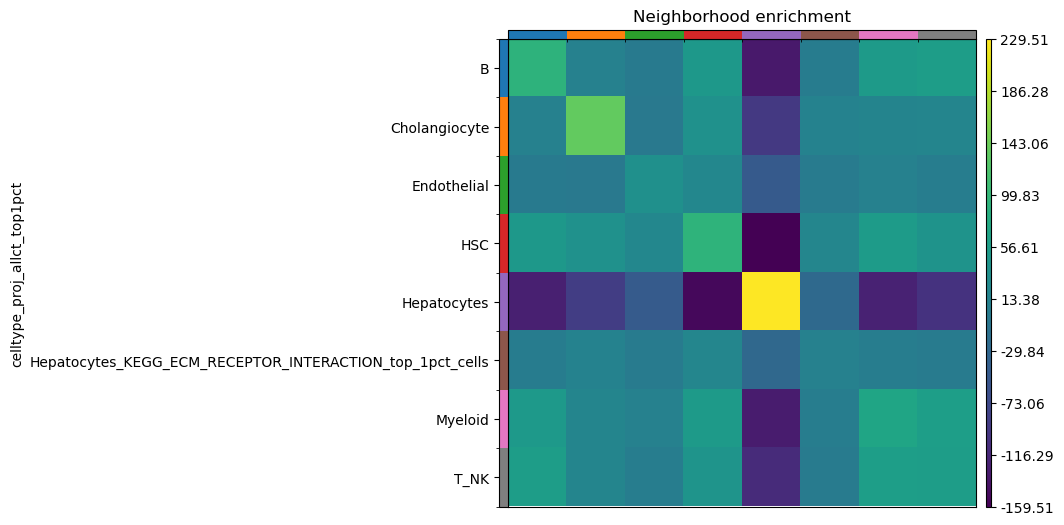

In [43]:
print(datetime.datetime.now())

sq.gr.spatial_neighbors(full_adata)
sq.gr.nhood_enrichment(full_adata, cluster_key="celltype_proj_allct_top1pct", show_progress_bar  = False) #with high fibrosis donors for tangram
sq.pl.nhood_enrichment(full_adata, cluster_key="celltype_proj_allct_top1pct")
print(datetime.datetime.now())


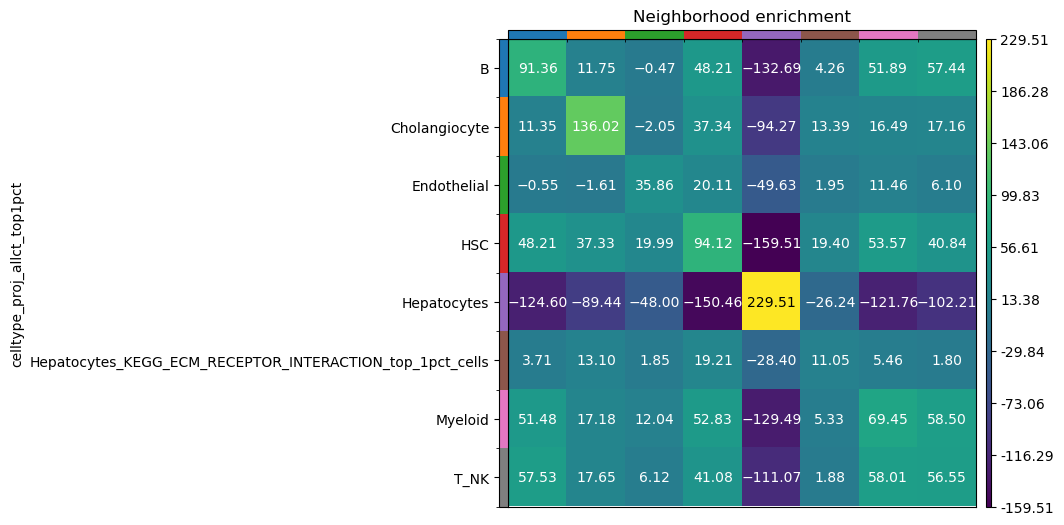

In [44]:
sq.pl.nhood_enrichment(full_adata, cluster_key="celltype_proj_allct_top1pct", annotate = True)


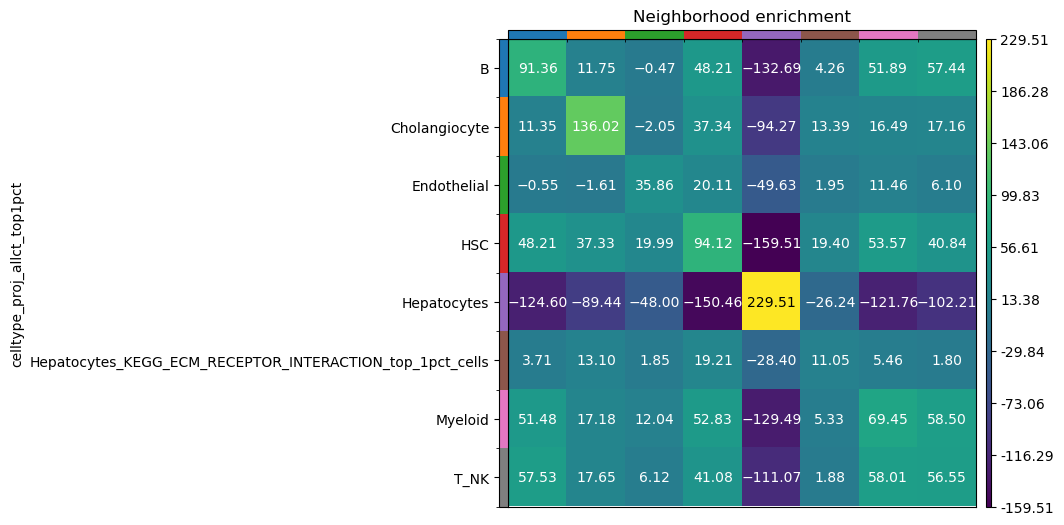

In [45]:
sq.pl.nhood_enrichment(full_adata, cluster_key="celltype_proj_allct_top1pct", annotate = True) #with match sen
plt.savefig(outp + 'enrich_mat_broad_ct.pdf', bbox_inches='tight')


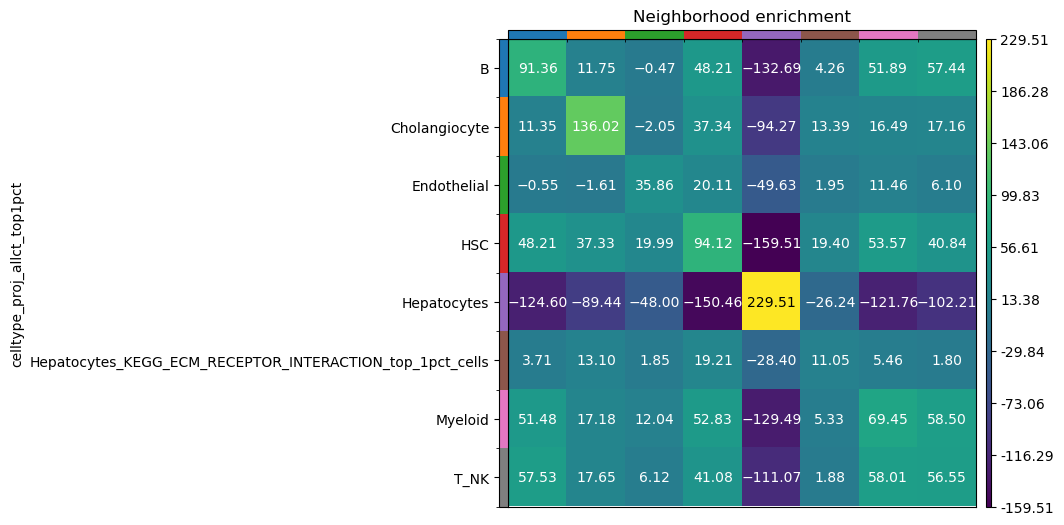

In [46]:
sq.pl.nhood_enrichment(full_adata, cluster_key="celltype_proj_allct_top1pct", annotate = True) #with match sen
plt.savefig(outp + 'enrich_mat_broad_ct_anno.pdf', bbox_inches='tight')


In [47]:
full_adata

AnnData object with n_obs × n_vars = 270311 × 17931
    obs: 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'clusters', 'uniform_density', 'rna_count_based_density', 'celltype_proj', 'pred_cell_types', 'celltype_proj_heps_top1pct', 'celltype_proj_allct_top1pct'
    uns: 'celltype_proj_colors', 'clusters', 'hvg', 'neighbors', 'pca', 'spatial', 'umap', 'spatial_neighbors', 'celltype_proj_allct_top1pct_nhood_enrichment'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_cropped', 'tangram_ct_pred'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [48]:
import seaborn as sns


In [49]:
ct_sort = full_adata.obs["celltype_proj_allct_top1pct"].unique().tolist()

In [50]:
ct_sort

['Hepatocytes',
 'B',
 'Endothelial',
 'Myeloid',
 'Cholangiocyte',
 'HSC',
 'T_NK',
 'Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells']

In [51]:
ct_sort.sort()

In [52]:
ct_sort

['B',
 'Cholangiocyte',
 'Endothelial',
 'HSC',
 'Hepatocytes',
 'Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells',
 'Myeloid',
 'T_NK']

In [53]:
heps_labels = ['Hepatocytes', 'Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells']

In [66]:
enrichment_df

NameError: name 'enrichment_df' is not defined

In [67]:
rows_to_plot

NameError: name 'rows_to_plot' is not defined

In [54]:
ct_sort

['B',
 'Cholangiocyte',
 'Endothelial',
 'HSC',
 'Hepatocytes',
 'Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells',
 'Myeloid',
 'T_NK']

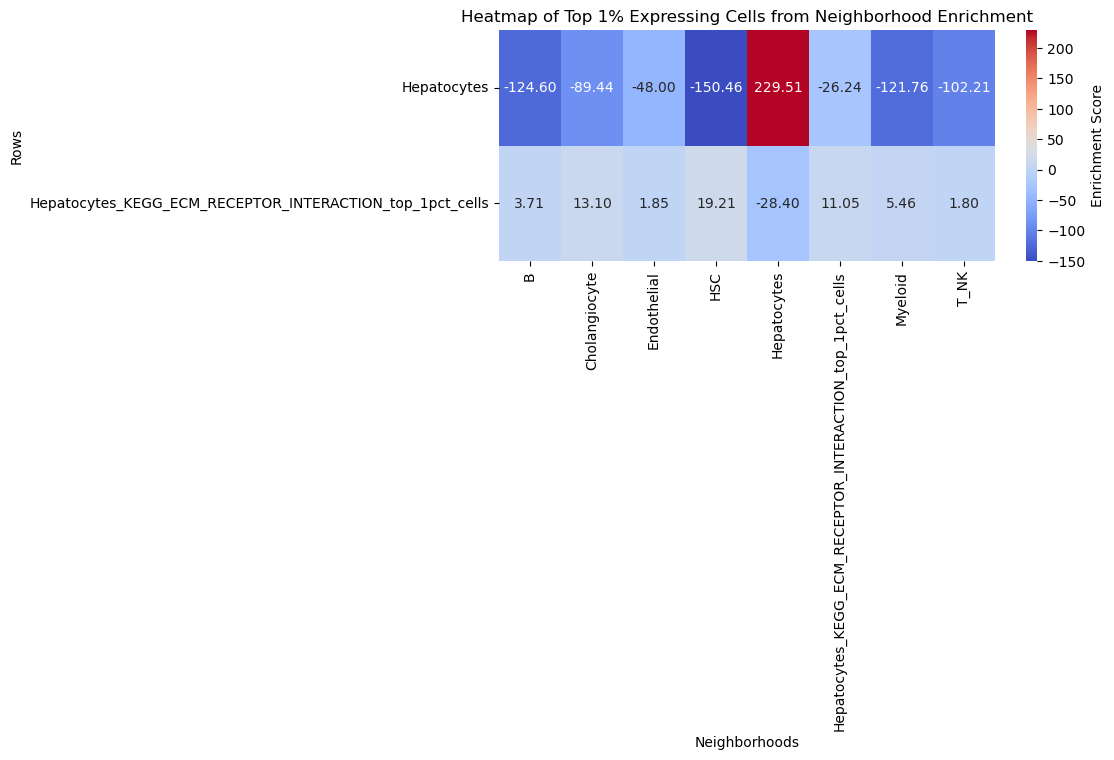

In [55]:
# Extract the enrichment data
enrichment_data = full_adata.uns['celltype_proj_allct_top1pct_nhood_enrichment']['zscore']

# Let's say we want to plot the first row (row index 0)
# You can select a row using numpy indexing or pandas
import pandas as pd

# Convert the enrichment data to a DataFrame if it's not already
enrichment_df = pd.DataFrame(enrichment_data)

# Select a single row (for example, the first row)
rows_to_plot = enrichment_df.iloc[4:6]  # Select the first row
#rows_to_plot = rows_to_plot.reindex([5, 4, 6, 7, 8])

# Reorder columns: Swap the 5th and 6th columns
col_indices = list(range(enrichment_df.shape[1]))  # Get all column indices
#col_indices[4], col_indices[5] = col_indices[5], col_indices[4]  # Swap columns 5 and 6
#rows_to_plot = rows_to_plot.iloc[:, col_indices]  # Reorder columns


rows_to_plot_values = rows_to_plot.values

# Plot the rows as a heatmap
plt.figure(figsize=(8, 3))  # Adjust height to fit multiple rows
sns.heatmap(rows_to_plot_values, cmap='coolwarm', fmt='.2f', annot=True, 
            xticklabels=[ct_sort[i] for i in col_indices], yticklabels=heps_labels, 
            cbar_kws={'label': 'Enrichment Score'})

# Add title and labels
plt.title("Heatmap of Top 1% Expressing Cells from Neighborhood Enrichment")
plt.xlabel("Neighborhoods")
plt.ylabel("Rows")
# Show the plot
plt.xticks(rotation=90)
#plt.yticks(rotation=90)


#plt.show()
plt.savefig(outp + 'enrich_mat_broad_ct_kegg_red_blue_only_all_heps.pdf', bbox_inches='tight')


In [56]:
col_names = [ct_sort[i] for i in col_indices]
col_names 

['B',
 'Cholangiocyte',
 'Endothelial',
 'HSC',
 'Hepatocytes',
 'Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells',
 'Myeloid',
 'T_NK']

In [57]:
row_names = heps_labels
row_names

['Hepatocytes', 'Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells']

In [58]:
cond_row_names = ["MASH_" + x for x in row_names]
cond_row_names

['MASH_Hepatocytes',
 'MASH_Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells']

In [59]:
outp

'/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/fnih_deg_pathways_module_score_mash/HL20221019_broad_no_mast_filt/'

In [60]:
f"{outp}_reactome_fatty_acids_neighbor.txt"

'/tscc/projects/ps-epigen/users/cmiciano/Liver/RNA/spatial/outputs/sandbox/fnih_deg_pathways_module_score_mash/HL20221019_broad_no_mast_filt/_reactome_fatty_acids_neighbor.txt'

In [61]:
cond_row_names

['MASH_Hepatocytes',
 'MASH_Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells']

In [62]:
row_names


['Hepatocytes', 'Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells']

In [63]:
df = pd.DataFrame(
    rows_to_plot_values ,
    index=cond_row_names,   # rownames
    columns=col_names 
)
# Save to CSV with rownames
df.to_csv(f"{outp}kegg_ecm_receptor_interaction_neighbor.txt", sep = "\t", index=True)
df

,B,Cholangiocyte,Endothelial,HSC,Hepatocytes,Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells,Myeloid,T_NK
MASH_Hepatocytes,-124.602637,-89.439938,-48.003949,-150.456140,229.506305,-26.236130,-121.760768,-102.214636
MASH_Hepatocytes_KEGG_ECM_RECEPTOR_INTERACTION_top_1pct_cells,3.711157,13.103815,1.852654,19.211558,-28.396084,11.048182,5.464218,1.801062


In [105]:
 sc.pl.spatial(
        adata,
        color=f"{pw_name}_score",
        size=5,
        img_key=None,
        title=plot_title,
        cmap=custom_white_red,
        vmax=cutoff,
        vmin = 0,
        show=False
    )

plt.savefig(f"{outp}{pw_name}_score_red_white_{p}th_percentile_vmin0.pdf", bbox_inches="tight")
plt.close()

/scratch/cmiciano/job_7072275/ipykernel_2483596/143510386.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


/scratch/cmiciano/job_7072275/ipykernel_2483596/3385439924.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


[<Axes: title={'center': 'KEGG_ECM_RECEPTOR_INTERACTION — Top 1% Cells: 1784 (≥ 99th percentile)'}, xlabel='spatial1', ylabel='spatial2'>]

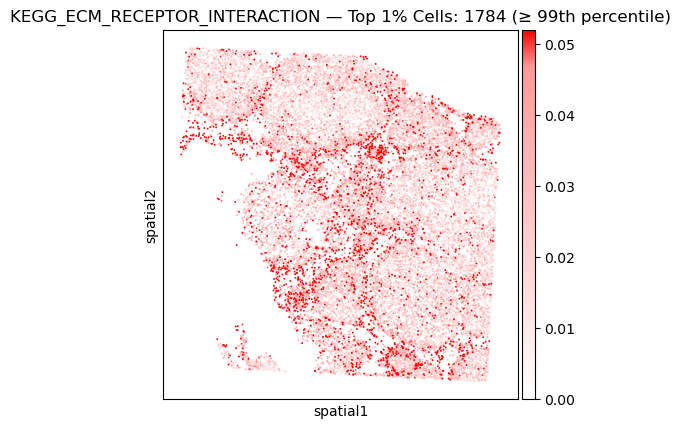

In [106]:
 sc.pl.spatial(
        adata,
        color=f"{pw_name}_score",
        size=5,
        img_key=None,
        title=plot_title,
        cmap=custom_white_red,
        vmax=cutoff,
        vmin = 0,
        show=False
    )


/scratch/cmiciano/job_7072275/ipykernel_2483596/4089384621.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


[<Axes: title={'center': 'KEGG_ECM_RECEPTOR_INTERACTION — Top 1% Cells: 1784 (≥ 99th percentile)'}, xlabel='spatial1', ylabel='spatial2'>]

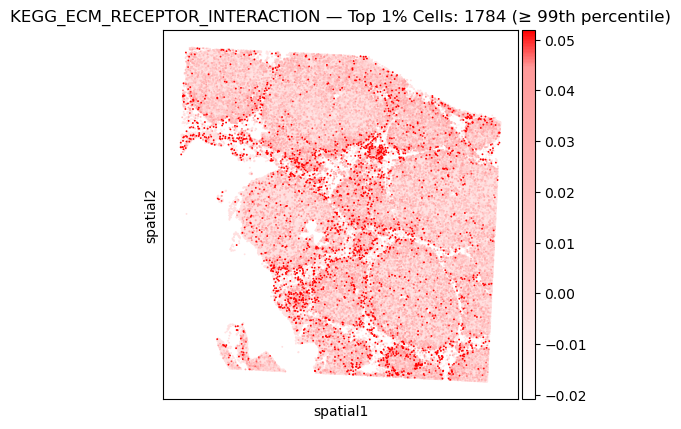

In [107]:
 sc.pl.spatial(
        adata,
        color=f"{pw_name}_score",
        size=5,
        img_key=None,
        title=plot_title,
        cmap=custom_white_red,
        vmax=cutoff,
        show=False
    )
